# Support Ticket Classification & Priority Prediction System

## Project Overview

This project uses Natural Language Processing (NLP) and Machine Learning to automatically classify customer support tickets and predict their priority level.


## Import Libraries

In [51]:
import pandas as pd

## Load Dataset


In [ ]:


df = pd.read_csv("../data/customer_support_tickets.csv")

df.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## Dataset Information

Exploring the dataset structure and identifying relevant features for ticket classification and priority prediction.

In [42]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


## Text Feature Selection

Selecting the ticket description as the input feature and ticket type as the target variable for classification.

In [43]:
X = df['Ticket Description']
y = df['Ticket Type']

In [44]:
X = df['Ticket Description']
y = df['Ticket Type']

print(X.head())
print(y.head())

0    I'm having an issue with the {product_purchase...
1    I'm having an issue with the {product_purchase...
2    I'm facing a problem with my {product_purchase...
3    I'm having an issue with the {product_purchase...
4    I'm having an issue with the {product_purchase...
Name: Ticket Description, dtype: object
0    Technical issue
1    Technical issue
2    Technical issue
3    Billing inquiry
4    Billing inquiry
Name: Ticket Type, dtype: object


## TF-IDF Vectorization

Converting textual ticket descriptions into numerical feature vectors using TF-IDF so that Machine Learning models can process them.

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_vectorized = vectorizer.fit_transform(X)

print(X_vectorized.shape)

(8469, 7195)


## Train-Test Split

Splitting the dataset into training and testing sets to evaluate model performance on unseen data.

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

## Ticket Type Classification

Training a Naive Bayes classifier to automatically categorize support tickets based on their descriptions.

In [47]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [48]:
predictions = model.predict(X_test)

## Ticket Type Model Evaluation

Evaluating the classification model using accuracy metrics.

In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.19657615112160567


## Ticket Priority Classification

Building a Machine Learning model to predict the priority level of customer support tickets.

In [50]:
X = df['Ticket Description']
y = df['Ticket Priority']

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_vectorized = vectorizer.fit_transform(X)

print(X_vectorized.shape)

(8469, 7195)


## Train-Test Split

The dataset is divided into training and testing sets.

- Training data is used to train the machine learning model.
- Testing data is used to evaluate model performance on unseen data.
- An 80-20 split is used with a fixed random state for reproducibility.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

A Multinomial Naive Bayes classifier is trained using the TF-IDF vectorized ticket descriptions.

This algorithm is widely used for text classification tasks because it is:
- Fast and efficient
- Suitable for high-dimensional text data
- Effective for Natural Language Processing applications

In [35]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Model Evaluation

The trained Multinomial Naive Bayes model is evaluated using the testing dataset.

Predictions are generated for unseen ticket descriptions and compared with actual ticket priorities to measure classification performance.

In [36]:
predictions = model.predict(X_test)

## Priority Prediction Accuracy

Measuring the performance of the ticket priority prediction model.

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Priority Prediction Accuracy:", accuracy)

Priority Prediction Accuracy: 0.24025974025974026


## Confusion Matrix

Visualizing model predictions against actual ticket priorities to better understand classification performance.

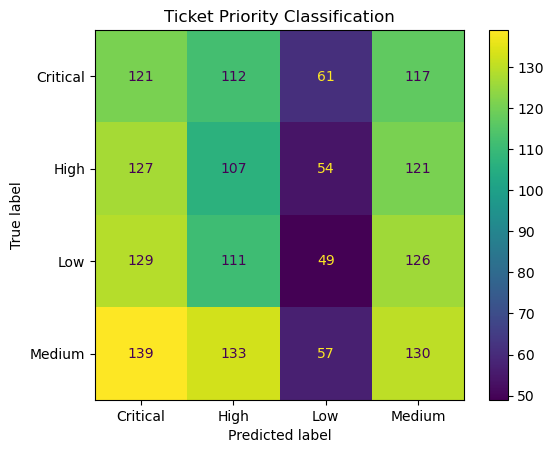

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.title("Ticket Priority Classification")
plt.show()

## Ticket Priority Distribution

Analyzing the distribution of support tickets across different priority levels.

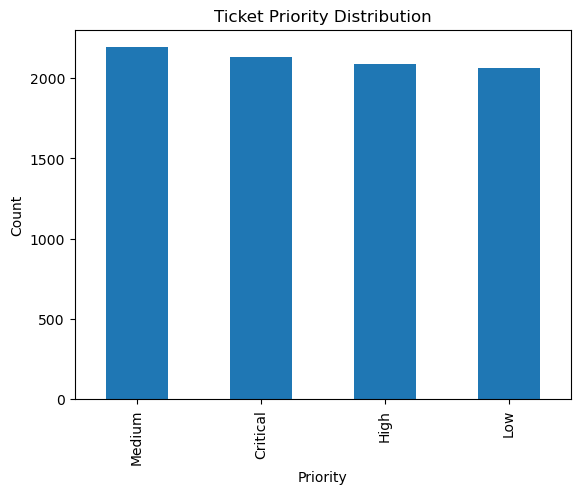

In [39]:
import matplotlib.pyplot as plt

df['Ticket Priority'].value_counts().plot(
    kind='bar'
)

plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")

plt.show()

## Real-Time Ticket Prediction

Testing the trained model on a new customer support ticket to simulate a real-world use case.

In [40]:
sample_ticket = [
    "Payment failed and money was deducted from my account"
]

sample_vector = vectorizer.transform(sample_ticket)

prediction = model.predict(sample_vector)

print("Predicted Priority:", prediction[0])

Predicted Priority: Critical


# Conclusion

This project successfully implements a Support Ticket Classification and Priority Prediction System using Natural Language Processing (NLP) and Machine Learning.

Key accomplishments:
- Loaded and explored customer support ticket data
- Applied TF-IDF text vectorization
- Classified ticket categories
- Predicted ticket priority levels
- Evaluated model performance
- Performed real-time ticket prediction

Results:
- Ticket Type Classification Accuracy: 19.66%
- Ticket Priority Prediction Accuracy: 24.03%

This project demonstrates practical applications of NLP, text classification, and customer support automation using Python and Scikit-learn.